# Deconvolve Chromatin Bins for CLB2

In this notebook, we will read from Yulong's replicate 2 dataset for a single gene, CLB2 to start, collect the MNase-seq reads for this gene. Then, compute a histogram (decide on the number of bins and fragment lengths), then perform a deconvolution on the values in the histogram over the time course using the deconvolution code.

Goal:
- Determine feasibility of deconvolving the occupancy values of the chromatin for a gene.
- That is, how many values can we deconvolve at once (how many bins can we realistically grid the gene into and get reasonable deconvolved values).

Steps:
1. Read MNase-seq reads for CLB2 for every time point.
2. Determine the histogram bins for the gene. Proof of concept so we can do something very basic to start.
3. Deconvolve the bin counts for the gene.
4. Analyze the results (peak to trough? summarize peak to trough for all of the bins for the gene?)

Note: Keep in mind normalization schemes, (copy number?)
Note: We will need to address the model changes for this dataset, RG1-CG1-DG1 vs R-CG1-DG1 model.

In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [192]:
from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()

In [195]:
chromatin_gridder.set_gene('CLB2')

In [223]:
chromatin_gridder.compute_bin_counts_sample(0)

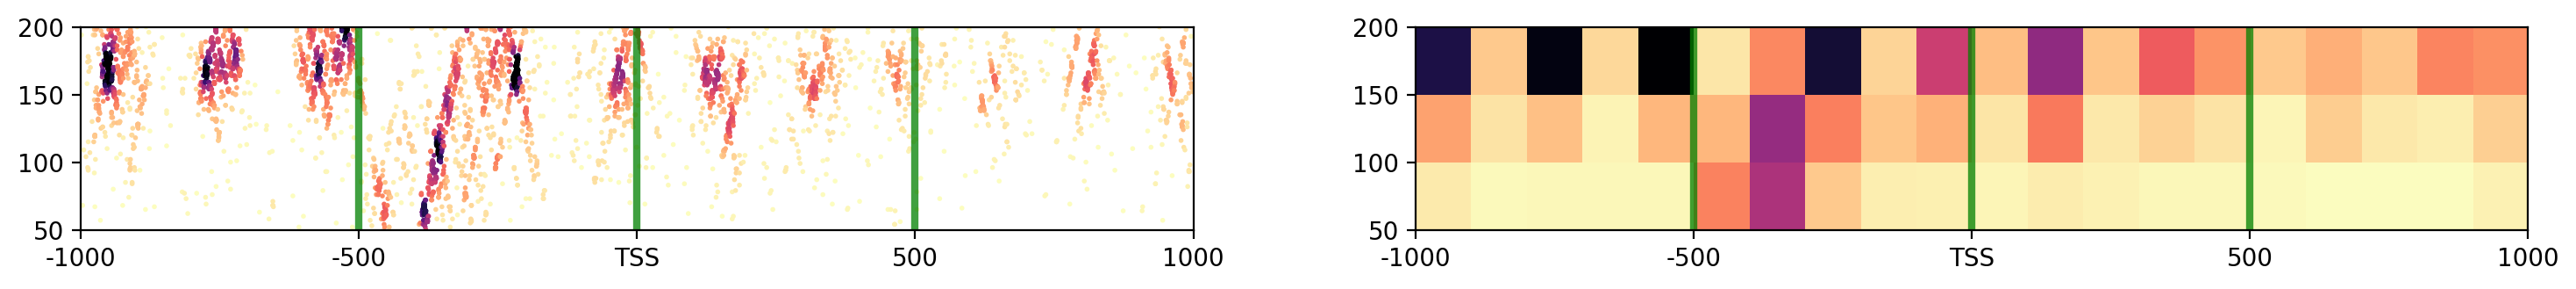

In [226]:
chromatin_gridder.plot()

In [237]:
print(f"The histogram shape for the 2000 bp window around the TSS:", chromatin_gridder.hist.shape)

The histogram shape for the 2000 bp window around the TSS: (20, 3)


In [238]:
# If we were to take the middle 10 bins (equivalent to 1000 bp window around the TSS), 
# Our histogram for this time point would look like:
print("The shape for the middle 10 bins (1000 bp around the TSS):", chromatin_gridder.hist[5:-5].shape)

# i.e. 30 values per timepoint

The shape for the middle 10 bins (1000 bp around the TSS): (10, 3)


In [239]:
# Next, let's try and do this plot for the entire time course for CLB2